# Today, I am building MNIST from scratch in 20 minutes. Let's see if I can do it.

# 1. Import Necessary packages

In [1]:
import torch
import torchvision

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn as nn

from torch import optim

Device

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple GPU)


# 2. Transforms, Datasets, Dataloaders

In [ ]:
# TRANSFORMS
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3), #grayscale 1 channel to 3
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

#DATASET
full_data = datasets.MNIST(root="./data_mnist",train=True,transform=test_transforms,download=False) #rmr to manually change to train transform after val split

main_num_classes = len(full_data.classes)
main_num_channels = full_data[0][0].shape[0]

train_size = int(0.8*len(full_data))
val_size = len(full_data)-train_size
split_lengths = [train_size,val_size]
train_dataset, val_dataset = random_split(full_data,split_lengths)

train_dataset.dataset.transform = train_transforms

test_dataset = datasets.MNIST(root="./data_mnist",train=False,transform=test_transforms,download=False)

#DATALOADERS
batch_size = 32
train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

Faq it, I'm doing both. own model, and then transfer learning. We shall see what is better

In [4]:
print(main_num_classes)
print(main_num_channels)

10
3


# 3. Model Class Definition

In [5]:
class CNN(nn.Module):

  def __init__(self,num_classes,num_channels):
    super().__init__()
    self.num_classes = num_classes
    self.num_channels = num_channels

    self.convStack = nn.Sequential(
      #CONV1
      nn.Conv2d(self.num_channels,32,3),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(2),

      #CONV2
      nn.Conv2d(32,64,3),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2),

      #CONV3
      nn.Conv2d(64,64,3),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2)
  )

    #CRITICAL
    with torch.no_grad():
      dummy = torch.randn(1,self.num_channels,224,224)
      x = self.convStack(dummy)
      flat_size = x.view(-1).shape[0]

    self.linearStack = nn.Sequential(
      nn.Linear(flat_size,64),
      nn.ReLU(),
      nn.Dropout(0.5),

      nn.Linear(64,128),
      nn.ReLU(),
      nn.Dropout(0.4),

      nn.Linear(128,64),
      nn.ReLU(),
      nn.Dropout(0.3)
    )

    self.fc = nn.Linear(64,self.num_classes)

  def forward(self,x):
    x = self.convStack(x)
    x = torch.flatten(x,1)
    x = self.linearStack(x)
    logits = self.fc(x)
    return logits

# 4. Optimizer, Loss_Fn, LR_Scheduler, EarlyStopping

In [6]:
model = CNN(main_num_classes,main_num_channels)
model = model.to(device)

optimizer = optim.Adam(model.parameters(),lr=0.0001)
loss_fn = nn.CrossEntropyLoss()
loss_fn = loss_fn.to(device)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50,eta_min=1e-6)

In [7]:
class EarlyStopping:

    def __init__(self,patience=5,min_delta=0):
        self.patience = patience #how many epochs to wait after last improvement
        self.min_delta = min_delta #minimum change to qualify as improvement
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self,val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                # kill it
                self.early_stop=True
        else:
            #here is the reset.
            self.best_loss = val_loss
            self.counter = 0

# 5. Training Loop

In [8]:
def train_loop_class(model, device, optimizer, loss_fn, lr_scheduler, train_dataloader, val_dataloader, train_losses, val_losses, model_save_path, early_stopping, epochs=50, initial_loss=float("inf")):

    best_loss = initial_loss

    for epoch in range(epochs):
        # == TRAINING ==
        model.train()
        train_loss = 0.0

        for X_train, y_train in train_dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad()
            y_pred = model(X_train)
            loss = loss_fn(y_pred, y_train)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        if ((epoch + 1) == 1) or ((epoch + 1) % 10 == 0):
            print(f"Epoch {epoch+1} ; Train Loss: {avg_train_loss:.4f}")

        # == VAL ==
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_val, y_val in val_dataloader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                y_pred = model(X_val)
                loss = loss_fn(y_pred, y_val)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        if ((epoch + 1) == 1) or ((epoch + 1) % 10 == 0):
            print(f"Epoch {epoch+1} ; Val Loss: {avg_val_loss:.4f}")

        # == LR Scheduling ==
        lr_scheduler.step()

        # == SAVE BEST MODEL ==
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), model_save_path)

        # == EarlyStopping ==
        if early_stopping is not None:  # just to be safe
            early_stopping(avg_val_loss)
            if early_stopping.early_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    return best_loss

In [9]:
train_losses = []
val_losses = []

In [10]:
model_save_path_s1 = "best_mnist_cnn.pth"
best_loss_s1 = train_loop_class(model, device, optimizer, loss_fn, lr_scheduler, train_dataloader, val_dataloader, train_losses, val_losses, model_save_path_s1, EarlyStopping(10,0.01), epochs=50, initial_loss=float("inf"))

Epoch 1 ; Train Loss: 1.3406
Epoch 1 ; Val Loss: 0.6582
EarlyStopping counter: 1/10
EarlyStopping counter: 1/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
Epoch 10 ; Train Loss: 0.6236
Epoch 10 ; Val Loss: 0.2426
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 3/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 3/10
EarlyStopping counter: 4/10
Epoch 20 ; Train Loss: 0.5531
Epoch 20 ; Val Loss: 0.2335
EarlyStopping counter: 5/10
EarlyStopping counter: 6/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 3/10
EarlyStopping counter: 4/10
Epoch 30 ; Train Loss: 0.4992
Epoch 30 ; Val Loss: 0.1833
EarlyStopping counter: 5/10
EarlyStopping counter: 6/10
EarlyStopping counter: 7/10
EarlyStopping counter: 8/10
EarlyStopping counter: 9/10
EarlyStopping counter: 10/10
Early stopping triggered at epoch 35


# Visualize Losses

In [11]:
import matplotlib.pyplot as plt

def plot_results(train_losses,val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

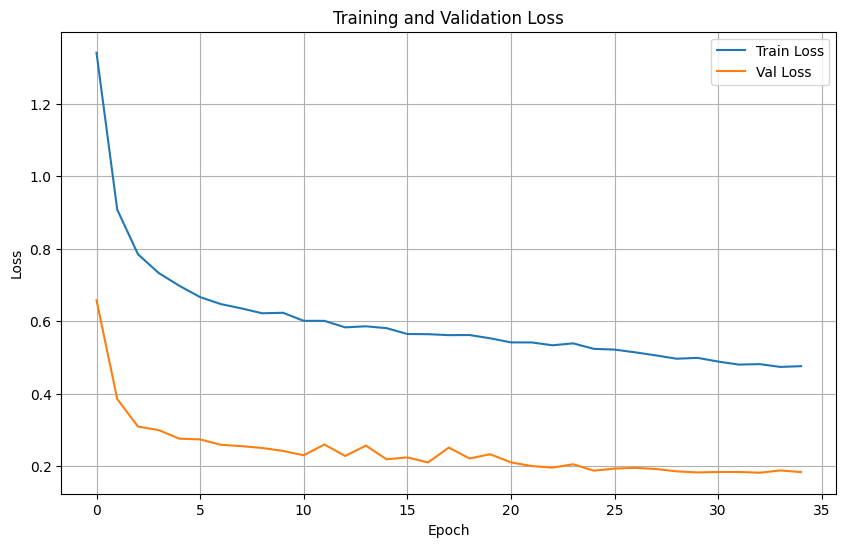

In [12]:
plot_results(train_losses,val_losses)

# Testing Loop

In [13]:
def test_loop(model,device,loss_fn,test_dataloader):

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X,y in test_dataloader:
            X = X.to(device)
            y = y.to(device)

            y_pred = model(X)
            loss = loss_fn(y_pred,y)

            test_loss += loss.item()

            _,predicted = torch.max(y_pred,1)
            correct+= (predicted==y).sum().item()
            total += y.size(0)

    avg_test_loss = test_loss/len(test_dataloader)
    test_accuracy = correct/total

    return avg_test_loss,test_accuracy

In [14]:
test_loss, test_acc = test_loop(model,device,loss_fn,test_dataloader)
print(test_loss,test_acc)

0.17177767992114867 0.959


So that's nice. Now I want to see what transfer learning does.

Everything stays the same up until model class definition.

In [15]:
#1. Load the model
model_tf = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

#2. Freeze all layers
for param in model_tf.parameters():
    param.requires_grad = False

#3. take a look at architecture
print(model_tf)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [17]:
print(model_tf.classifier[1])

Linear(in_features=1280, out_features=1000, bias=True)


In [18]:
#start new cell pan

#4. Clip output layer to your needs
orig_num_feats = model_tf.classifier[1].in_features
model_tf.classifier[1] = nn.Linear(orig_num_feats,main_num_classes)

#5. If this is exactly how it all played out, then optimize
optimizer_tf = optim.Adam(model_tf.classifier[1].parameters(),lr=0.0001)
loss_fn_tf = nn.CrossEntropyLoss()
loss_fn_tf = loss_fn_tf.to(device)
lr_scheduler_tf = optim.lr_scheduler.CosineAnnealingLR(optimizer_tf,T_max=50,eta_min=1e-7)

In [19]:
train_losses_tf = []
val_losses_tf = []

In [20]:
best_loss_s1

0.18248225836455823

In [21]:
model_tf = model_tf.to(device)
model_save_path_t1 = "best_mnist_mvn2.pth"
best_loss_tf1 = train_loop_class(model_tf, device, optimizer_tf, loss_fn_tf, lr_scheduler_tf, train_dataloader, val_dataloader, train_losses_tf, val_losses_tf, model_save_path_t1, EarlyStopping(7,0.01), epochs=50, initial_loss=float("inf"))

Epoch 1 ; Train Loss: 1.4405
Epoch 1 ; Val Loss: 0.9496
EarlyStopping counter: 1/7
Epoch 10 ; Train Loss: 0.4019
Epoch 10 ; Val Loss: 0.3492
EarlyStopping counter: 1/7
EarlyStopping counter: 1/7
EarlyStopping counter: 1/7
EarlyStopping counter: 2/7
EarlyStopping counter: 3/7
EarlyStopping counter: 4/7
Epoch 20 ; Train Loss: 0.3465
Epoch 20 ; Val Loss: 0.2923
EarlyStopping counter: 1/7
EarlyStopping counter: 2/7
EarlyStopping counter: 3/7
EarlyStopping counter: 4/7
EarlyStopping counter: 5/7
EarlyStopping counter: 6/7
EarlyStopping counter: 1/7
EarlyStopping counter: 2/7
Epoch 30 ; Train Loss: 0.3233
Epoch 30 ; Val Loss: 0.2802
EarlyStopping counter: 3/7
EarlyStopping counter: 4/7
EarlyStopping counter: 5/7
EarlyStopping counter: 6/7
EarlyStopping counter: 7/7
Early stopping triggered at epoch 34


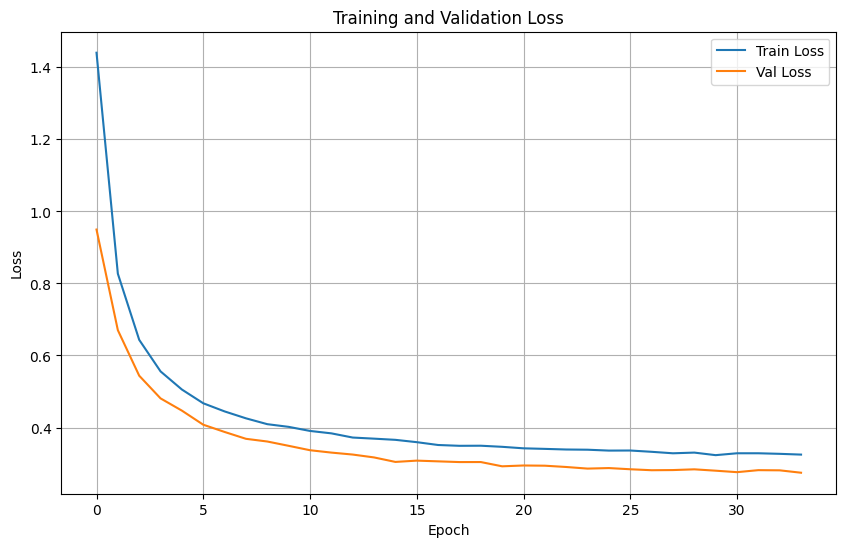

In [22]:
plot_results(train_losses_tf,val_losses_tf)

In [25]:
model_tf.load_state_dict(torch.load("best_mnist_mvn2.pth"))
model_tf = model_tf.to(device)
test_loss_tf, test_acc_tf = test_loop(model_tf,device,loss_fn_tf,test_dataloader)
print(test_loss_tf,test_acc_tf)

/var/folders/j6/nvqwll1n4rxg2f3xyd5_41lc0000gn/T/ipykernel_62873/2315845320.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_tf.load_state_dict(torch.load("best_mni

0.26900659615810685 0.9137
